In [ ]:
##### /*--*/
* Como se consigue sacar usuarios con alta intencidad y poco pasos ??? 
* Fomatos de variables, funciones y clases

# Notas
* Segun las investigaciones de la actividad física de la directrices de la **OMS** menciona que las personas de **18 a 64** años deberían hacer actividades de fortalecimiento muscular de intensidad moderada al menos **2 días** a la semana para tener beneficios adicionales para la salud.


# Revisar

- Los datos trabajan con mets de 6 como intensidad 3 como último nivel, siende que podría generar más grados de este para deportistas o acciones simliares. Identificando estos parametros puedo concluir que el registro de parametros no está enfocada a deportistas. Pero sí a usuarios que se encuentra en reposo hasta actividades moderados, como trote o baile


### Implicaciones Estratégicas y Recomendaciones (según correlaciones formato minutos)

La alta correlación entre las métricas tiene dos implicaciones directas para la estrategia de marketing y el diseño de la aplicación:

#### 1. Enfoque en la Métrica de Mayor Impacto (No me gusta)

* **Recomendación:** Dado que la **Intensidad** tiene la correlación más alta con el gasto calórico (objetivo principal de fitness), se debe usar en la comunicación para **validar el esfuerzo del usuario**.
* **Marketing:** Las campañas deben enfocarse en cómo el dispositivo ayuda a los usuarios a optimizar su tiempo, enfatizando: *"Más Intensidad = Resultados más Rápidos y Medibles."*

#### 2. Validación de Durabilidad y Resistencia (El Mejor)

* **Recomendación:** La alta correlación entre **Intensidad** y **Pasos** confirma que los usuarios más activos exigen un rendimiento constante.
* **Marketing:** Refuerza la campaña de **durabilidad** y **resistencia** del dispositivo, ya que los usuarios no solo dan muchos pasos, sino que lo hacen con un alto nivel de exigencia. El mensaje es: **"Nuestro dispositivo soporta el ritmo que marcan tus mejores días."**


---

# FitBit

## Recursos de investigación

### Actividad saludables según los pasos - Relationship of Daily Step Counts to All-Cause Mortality and Cardiovascular Events

https://www.jacc.org/doi/10.1016/j.jacc.2023.07.029

Meta-análisis para cuantificar las asociaciones dosis-respuesta de las métricas de recuento de pasos medidas objetivamente en la población general.

### Directrices de la OMS sobre actividad física y comportamientos sedentarios

https://iris.who.int/items/65310979-92e8-4c98-8092-5a16ca07fc2f

Actividad recomendada entre 150 a 300 minutos de actividad moderada semanales para persona de 18 a 64 años
de momento se usara el punto medio que sería 225 para el punto optimo y también el minimo de 150. estos serán separados en a lo largo de los 7 días de la semana


## Importar librerías

In [3]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
from datetime import datetime

# --- Directory and Path Configuration ---

# Base directory for the original data (lambda function for dynamic date range)
base_dir   = lambda date: f"./data/export_{date}"

# list of dir names
dates_list = ['3.12.16-4.11.16', '4.12.16-5.12.16']

original_activity1 = pd.read_csv(f'{base_dir(dates_list[0])}/dailyActivity.csv')
original_activity2 = pd.read_csv(f'{base_dir(dates_list[1])}/dailyActivity.csv')


## Funciones 

### Funciones iniciales e integración de columnas

In [ ]:
# Limit data range from dataframe
def limit_date_range(df, date_range, activity = 'ActivityDay'):
    """ From a DataFrame use data range from name directory

        Args:
            df (pd.DataFrame) : DataFrame with all info from users.
            date_range  (str) : Data range on string format (%m.%d.%y-%m.%d.%y).

        Returns:
            df_dailyActivity (pd.DataFrame) : Merged DataFrame with Daily info from all users.
    """
    sep_dates = date_range.split('-')
    initial_date = str(datetime.strptime(sep_dates[0], '%m.%d.%y').date())
    last_date    = str(datetime.strptime(sep_dates[1], '%m.%d.%y').date())

    range = df[(df[activity] >= initial_date) & (df[activity] <= last_date)]
    return range

# Merge dataframes de las fechas
def connect_dailyActivity_files(dates_list = dates_list, time_type = 'daily', info_type = 'Activity' , time_activity = 'ActivityDay'):
    """ Read and merges multiple csv dailys info from all users.
##############################################################################
        Args:
            dates_list (list)  : listado con de las direcciones donde se encuentran los archivos 

        Returns:
            df_dailyActivity (pd.DataFrame) : Merged DataFrame with Daily info from all users.
    """
    df_dailyActivity = pd.read_csv(f'{base_dir(dates_list[0])}/{time_type}{info_type}.csv')
    df_dailyActivity = limit_date_range(df_dailyActivity, dates_list[0], time_activity)
    for date in dates_list[1:]:
        df_con = pd.read_csv(f'{base_dir(date)}/{time_type}{info_type}.csv')
        df_con = limit_date_range(df_con, date, time_activity)
        df_dailyActivity = pd.merge(
                df_dailyActivity, 
                df_con, 
                how='outer'
            )
    
    df_dailyActivity[time_activity] = pd.to_datetime(df_dailyActivity[time_activity]) # Formato fecha
    return df_dailyActivity


######################################################################
# VARIABLES BASADA EN SALUD
# *** Metas Diarias Intensidad (Basado en OMS) ***
LI_INTENSITY_GOAL_VALUES = [0 , 22, 32, 43, np.inf]
LI_INTENSITY_GOAL_NAMES  = ['Flag_Sedentary', 'Flag_Meets_Min_Health',  'Flag_Meets_Optimal_Goal',  'Flag_Meets_Best_Goal']
LI_INTENSITY_NAMES_ESP  =  ['Sedentario', 'Mínimo Saludable' , 'Objetivo Óptimo' , 'Objetivo Máximo']

# *** Cantidad de pasos diarios ***
LI_STEPS_GOAL_VALUES    = [0, 2735, 4844, 7170, 10000, np.inf]
LI_STEPS_ROWS_NAMES_ESP = ['Sedentario', 'Mínimo', 'leve', 'Óptimo', 'Muy Activo']
######################################################################


def add_info_columns(df, li_goal_names = LI_INTENSITY_GOAL_NAMES, li_goal_values = LI_INTENSITY_GOAL_VALUES):
    user_df = df.copy()

    #  Columna con el número de la semana según el estándar ISO 8601
    user_df['Week_ISO'] = user_df['ActivityDay'].dt.isocalendar().week

    # *** Cálculo del Puntaje Combinado (Activity Score) ***
    # The Pondered Score reflects the effective volume of exercise.
    # 1 minute Vigorosa (Int 3) = 2 minutes Moderada (Int 2)
    # Calculo basado en el ejercicio que deber realizar una persona de 18 a 64 de manera semanal 
    user_df['Combined_Activity_Score'] = (user_df['VeryActiveMinutes'] * 2) + user_df['ModeratelyActiveMinutes']

    # *** Creación de Flags de Cumplimiento ***
    if (li_goal_values[-1] != np.inf) & (len(li_goal_names) == len(li_goal_values)):
        li_goal_values.append(np.inf)

    if len(li_goal_names)+1 == len(li_goal_values):
        for i in range(0, len(li_goal_names)):
            user_df[li_goal_names[i]] = np.where(
                ((user_df['Combined_Activity_Score'] >= li_goal_values[i]) & (user_df['Combined_Activity_Score'] < li_goal_values[i+1])), 
                1, # 1 if True
                0  # 0 if False
            )
    
    return user_df
    

### Análisis de Correlación en minutos: Intensidad, Pasos y Gasto Calórico

El siguiente análisis examina la relación entre las métricas de **Intensidad de la Actividad (en minutos)**, **Pasos diarios** y **Gasto Calórico**, utilizando el coeficiente de correlación de Pearson.

| | **Intensidad** | **Calorías** | **Pasos** |
| :--- | :--- | :--- | :--- |
| **Intensidad** | 1.0 | **0.911** | 0.852 |
| **Calorías** | **0.911** | 1.0 | 0.833 |
| **Pasos** | 0.852 | 0.833 | 1.0 |

Los resultados muestran una **correlación positiva, fuerte y muy significativa** entre las tres métricas clave, lo que valida la coherencia de los datos registrados por los dispositivos.

* **Intensidad y Calorías (r = 0.911):** Esta es la correlación más fuerte. Esto implica que el **tiempo dedicado a actividades de intensidad moderada o vigorosa** es el principal motor del gasto calórico. A mayor intensidad, mayor quema de calorías de forma muy predecible.
* **Intensidad y Pasos (r = 0.852):** Existe una fuerte relación entre la intensidad y la cantidad de pasos. Un aumento en la intensidad se traduce en un incremento considerable en el volumen de pasos.
* **Calorías y Pasos (r = 0.833):** La cantidad de pasos es un excelente predictor del gasto calórico del usuario, como es esperado.


In [5]:
# Obtener información em formato minutos de: Intensidad, Calorias, Pasos.
minutes_intensities = connect_dailyActivity_files(dates_list, time_type = 'minute', info_type = 'Intensities' , time_activity = 'ActivityMinute')
minutes_calories    = connect_dailyActivity_files(dates_list, time_type = 'minute', info_type = 'Calories'    , time_activity = 'ActivityMinute')
minutes_steps       = connect_dailyActivity_files(dates_list, time_type = 'minute', info_type = 'Steps'       , time_activity = 'ActivityMinute')

# Combinar Dataframes de cormatos minutos 
dfs_minutes_merged = pd.merge(
        minutes_intensities,
        minutes_calories,
        on=['Id', 'ActivityMinute'],
        how='left'
    )
dfs_minutes_merged = pd.merge(
        dfs_minutes_merged,
        minutes_steps,
        on=['Id', 'ActivityMinute'],
        how='left'
    )

# Correlaciones
dfs_minutes_merged[['Intensity' , 'Calories' , 'Steps' ]].corr()


,Intensity,Calories,Steps
Intensity,1.000000,0.911222,0.852119
Calories,0.911222,1.000000,0.832869
Steps,0.852119,0.832869,1.000000


In [6]:
# Creación de DataFrame con los datos diarios combinados 
merged_dailyActivity = connect_dailyActivity_files()

# Integrar columnas claves de tiempo e intensidad
merged_dailyActivity = add_info_columns(merged_dailyActivity)
merged_dailyActivity

,Id,ActivityDay,Calories,minutes_instances,SedentaryMinutes,LightActiveMinutes,ModeratelyActiveMinutes,VeryActiveMinutes,Steps,TotalMinutesAsleep,HalfDream,MinutesInBed,SleepsInstances,Week_ISO,Combined_Activity_Score,Flag_Sedentary,Flag_Meets_Min_Health,Flag_Meets_Optimal_Goal,Flag_Meets_Best_Goal
0,1503960366,2016-03-12,2228,1440,1056,216,60,108,19675,0.0,0.0,0.0,0.0,10,276,0,0,0,1
1,1503960366,2016-03-13,2101,1440,1106,197,32,105,17106,411.0,15.0,0.0,1.0,10,242,0,0,0,1
2,1503960366,2016-03-14,1829,1440,1142,228,28,42,10023,354.0,27.0,5.0,1.0,11,112,0,0,0,1
3,1503960366,2016-03-15,2112,1440,1037,260,87,56,15384,312.0,16.0,7.0,1.0,11,199,0,0,0,1
4,1503960366,2016-03-16,1965,1440,1122,198,55,65,13498,333.0,28.0,5.0,2.0,11,185,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1930,8877689391,2016-05-08,2844,1440,1169,139,93,39,10665,0.0,0.0,0.0,0.0,18,171,0,0,0,1
1931,8877689391,2016-05-09,3700,1440,1080,148,117,95,20156,0.0,0.0,0.0,0.0,19,307,0,0,0,1
1932,8877689391,2016-05-10,2830,1440,1179,136,85,40,10693,0.0,0.0,0.0,0.0,19,165,0,0,0,1
1933,8877689391,2016-05-11,3828,1440,1083,137,114,106,21391,0.0,0.0,0.0,0.0,19,326,0,0,0,1


### Creación de DataFrames de usuarios e Integración de columnas adicionales

In [7]:
# Rango de fechas del dataframe combinado 
first_day       = merged_dailyActivity['ActivityDay'].min()
last_day        = merged_dailyActivity['ActivityDay'].max()
diff_days_range = (last_day - first_day).days + 1 

print("*** Datos rango de datos de las fechas ***")

print()

print(first_day)
print(last_day)

print()

print(f'Cantidad de días    : {diff_days_range}')
print(f'Cantidad de horas   : {diff_days_range * 24}')
print(f'Cantidad de minutos : {diff_days_range * 1440}')

print()



*** Datos rango de datos de las fechas ***

2016-03-12 00:00:00
2016-05-12 00:00:00

Cantidad de días    : 62
Cantidad de horas   : 1488
Cantidad de minutos : 89280



### Filtrar los usuarios en el rango definido

In [8]:
# Filtrar usuarios antes

# Contar cantidad de días por usuario
count_user_days = merged_dailyActivity.groupby(['Id',]).agg(
    count_Records = ('ActivityDay', 'count')
)

# Filtar por cantidad mínima de 56 días (8 semanas)
count_user_days = count_user_days[count_user_days['count_Records'] > 56]

# Filtrar registros diarios a partir de listado filtrado de usuarios 
merged_dailyActivity = merged_dailyActivity[merged_dailyActivity['Id'].isin(count_user_days.index.to_list())]


## - Agrupar los registros por el id de los usuarios, para ver los rangos, cantidad de datos

Agrupa los datos del DataFrame por usuario de inicio a fin

In [9]:
# 
user_activity = merged_dailyActivity.groupby(['Id',]).agg(
    # Primer y ultima fecha disponible del usuario
    initial_date = ('ActivityDay', 'min'),         # Find the earliest available date
    lastest_date = ('ActivityDay', 'max'),         # Find the lastest available date

    # Días con datos registrados
    count_Records = ('ActivityDay', 'count'), 
    no_Records    = ('ActivityDay', lambda x : diff_days_range - x.count()),

    # Días que tienen todos sus datos registrados (1440 minutos)
    full_days       = ('minutes_instances', lambda x: (x == 1440).sum()), # Tiene todos los datos de los días
    incomplete_days = ('minutes_instances', lambda x: (x != 1440).sum()), # Tiene menos de la cantidad diaria de minutos
    
    # *** Sección Calorías ***
    average_calories = ('Calories', 'mean'),
    median_calories = ('Calories', 'median'),

    # *** Sección Pasos ***
    median_steps    = ('Steps', 'median'),

    # Categorías según la cantidad de pasos a lo largo del día 
    mov_Sedentary   = ('Steps', lambda x: ((x >= LI_STEPS_GOAL_VALUES[0]) & (x < LI_STEPS_GOAL_VALUES[1])).sum()),
    mov_min         = ('Steps', lambda x: ((x >= LI_STEPS_GOAL_VALUES[1]) & (x < LI_STEPS_GOAL_VALUES[2])).sum()),
    mov_Light       = ('Steps', lambda x: ((x >= LI_STEPS_GOAL_VALUES[2]) & (x < LI_STEPS_GOAL_VALUES[3])).sum()),
    mov_Optimal     = ('Steps', lambda x: ((x >= LI_STEPS_GOAL_VALUES[3]) & (x < LI_STEPS_GOAL_VALUES[4])).sum()),
    mov_VeryActive  = ('Steps', lambda x: ((x >= LI_STEPS_GOAL_VALUES[4]) & (x < LI_STEPS_GOAL_VALUES[5])).sum()),


    # *** Sección Intensidad ***
    intensities_median         = ('Combined_Activity_Score', 'median'),
    
    # Puntos de actividad
    Combined_Activity_Score    = ('Combined_Activity_Score', 'sum'),

    # Días con actividad física y suficiente
    Flag_Sedentary           = ('Flag_Sedentary', 'sum'),
    Flag_Meets_Min_Health    = ('Flag_Meets_Min_Health', 'sum'),
    Flag_Meets_Optimal_Goal  = ('Flag_Meets_Optimal_Goal', 'sum'),
    Flag_Meets_Best_Goal     = ('Flag_Meets_Best_Goal', 'sum'),
    

    # *** Sección Sueño ***
    # Días que tienen registrado su actividad de sueño y si estos son de  sueño saludable ( mínimo 7 horas)
    days_of_sleep  = ('TotalMinutesAsleep', lambda x: (x > 0).sum()),
    healthy_sleep  = ('TotalMinutesAsleep', lambda x: (x > 420).sum()),

)


### -. Prueba Visual: Diagrama de Dispersión (Volumen vs. Intensidad)

El Diagrama de Dispersión valida visualmente la **fuerte correlación positiva** ($\mathbf{r > 0.88}$) entre el **Volumen de Pasos** y el **Puntaje de Intensidad Combinada** (Minutos Efectivos). Cada punto representa un día de actividad registrado.

#### Hallazgos Clave:

* **Validación de la Tendencia:** La nube de puntos sigue una clara **trayectoria ascendente**, confirmando que los Pasos son el principal factor que impulsa la intensidad efectiva.
* **Concentración en el Riesgo:** La alta densidad de puntos cerca del origen ($\text{Pasos} < 5,000$) valida la existencia del **Segmento de Riesgo Crónico** y los días de baja actividad.
* **Aumento de la Variabilidad:** La **dispersión (ensanchamiento)** de los puntos en los rangos más altos de Pasos (sobre los $15,000$) indica que la eficiencia de la actividad varía significativamente entre los usuarios.
    * *Implicación:* Algunos usuarios son más eficientes (alta intensidad con menos pasos), mientras que otros requieren un volumen de pasos mucho mayor para lograr la misma intensidad. Esto refuerza la necesidad de analizar la **calidad (Intensidad)** sobre solo la **cantidad (Pasos)**.

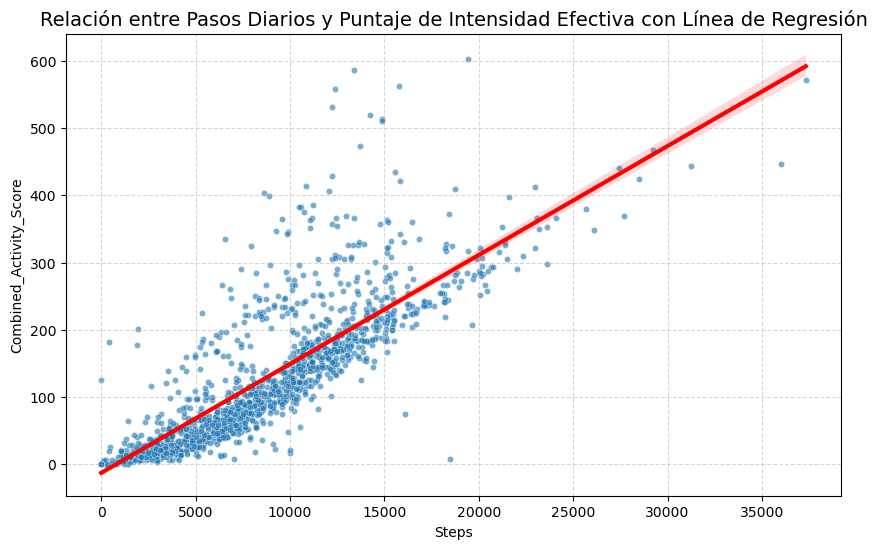

In [10]:
plt.figure(figsize=(10, 6))
# 1. Crear el diagrama de dispersión de base (como ya lo hiciste)
sns.scatterplot(
    x='Steps',                       
    y='Combined_Activity_Score',      
    data=merged_dailyActivity,
    alpha=0.6,
    s=20
)

# 2. AÑADIR LA LÍNEA DE REGRESIÓN
# sns.regplot calcula y dibuja la línea que mejor se ajusta a los datos (mínimos cuadrados)
sns.regplot(
    x='Steps',                       
    y='Combined_Activity_Score',      
    data=merged_dailyActivity,
    scatter=False, # Importante: No dibujar los puntos de nuevo
    color='red',   # Color de la línea de ajuste
    line_kws={'lw': 3} # Ancho de la línea
)

plt.title('Relación entre Pasos Diarios y Puntaje de Intensidad Efectiva con Línea de Regresión', fontsize=14)
# ... [otras etiquetas y leyendas] ...
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

---
## - Categorizar usuarios

### Categoría usuarios con dependeindo de la cantidad de pasos frente a la intensidad
Segmentos Clave Identificados (Conteo de Usuarios)

La segmentación cruzada del comportamiento de Pasos e Intensidad dio como resultado los siguientes grupos de usuarios:

| Categoría de Pasos Típicos | Intensidad Típica (Moda) | Conteo de Usuarios | Implicación del Comportamiento |
| :--- | :--- | :--- | :--- |
| **Sedentario/Mínimo** | **Riesgo Crónico** ($< 22 \text{ min}$) | **6 Usuarios** | Inactividad sistémica (fallan el mínimo de salud). |
| **Óptimo/Muy Activo** | **Máximo Rendimiento** ($\ge 43 \text{ min}$) | **15 Usuarios** | Alto compromiso y rendimiento sostenido. |


In [11]:
###### Usuarios catalogados por las medianas de pasos frente a intensidad

user_activity['healthy_steps'] = pd.cut(
    user_activity['median_steps'],    # Columna a clasificar
    bins   = LI_STEPS_GOAL_VALUES,    # Los límites definidos
    labels = LI_STEPS_ROWS_NAMES_ESP, # Las etiquetas definidas
    right  = False                    # El límite izquierdo es inclusivo ([0, 5000))
)

user_activity['intensities'] = pd.cut(
    user_activity['intensities_median'], # Columna a clasificar
    bins   = LI_INTENSITY_GOAL_VALUES,   # Los límites definidos
    labels = LI_INTENSITY_NAMES_ESP,     # Las etiquetas definidas
    right  = False                       # El límite izquierdo es inclusivo ([0, 5000))
)

df_segmentation_count = pd.crosstab(
    # La columna que quieres en las filas
    user_activity['healthy_steps'], 
    # La columna que quieres en las columnas
    user_activity['intensities'],
)

df_segmentation_count


intensities,Sedentario,Mínimo Saludable,Objetivo Óptimo,Objetivo Máximo
healthy_steps,,,,
Sedentario,3,0,1,0
Mínimo,3,2,0,0
leve,0,0,0,2
Óptimo,0,0,0,8
Muy Activo,0,0,0,7


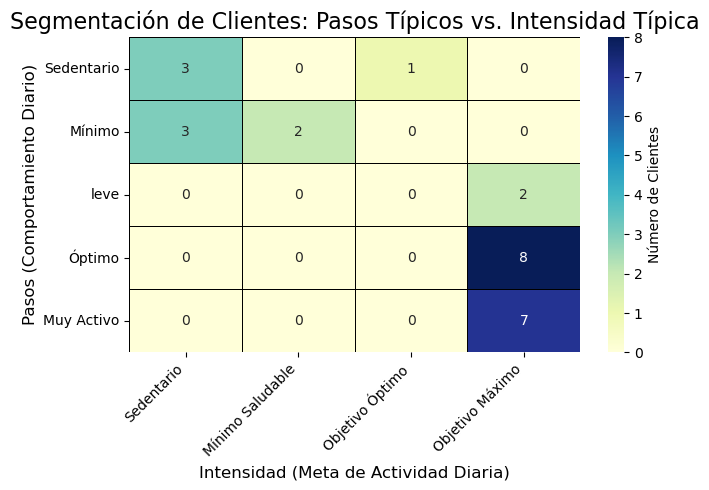

In [12]:
# Asumiendo que df_segmentation_count es tu DataFrame con el conteo de clientes

# 1. Definir el orden de las columnas de Intensidad (para una mejor narrativa visual)
# Asegúrate de que las columnas existan en tu DataFrame
column_order = LI_INTENSITY_NAMES_ESP

# Asegúrate de que las filas de pasos también estén en un orden lógico
# (ej. de Sedentario a Muy Activo)
row_order = LI_STEPS_ROWS_NAMES_ESP

# Reindexar el DataFrame para asegurar el orden visual deseado
df_plot_heatmap = df_segmentation_count.reindex(index=row_order, columns=column_order)


# 2. Crear el Mapa de Calor
plt.figure(figsize=(7, 5)) # Ajusta el tamaño según sea necesario

sns.heatmap(
    df_plot_heatmap,
    annot=True,        # Mostrar los números dentro de las celdas
    fmt="g",           # Formato general para los números (sin decimales para conteo)
    cmap="YlGnBu",     # Mapa de color (Yellow-Green-Blue, o elige otro como "Reds", "Greens")
    linewidths=.5,     # Líneas entre las celdas
    linecolor='black', # Color de las líneas
    cbar_kws={'label': 'Número de Clientes'} # Etiqueta para la barra de color
)

# 3. Añadir etiquetas y título
plt.title('Segmentación de Clientes: Pasos Típicos vs. Intensidad Típica', fontsize=16)
plt.xlabel('Intensidad (Meta de Actividad Diaria)', fontsize=12)
plt.ylabel('Pasos (Comportamiento Diario)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0) # Para que las etiquetas de las filas no estén rotadas
plt.tight_layout()
plt.show()

###  El Cliente Eficiente (Discrepancia Clave)

* Mediana de días en Riesgo (36.0): El cliente cuyo comportamiento típico es sedentario pasa la mediana de $\mathbf{36}$ días (de un total de $\approx 62$ días) sin alcanzar el umbral mínimo de salud.

* Mediana de días en Alto Rendimiento (61.0): El cliente cuyo comportamiento típico es dar muchos pasos tiene la mediana de $\mathbf{61}$ días donde logra el máximo esfuerzo.


Se detectó un segmento minoritario donde la **intensidad es alta a pesar de un volumen de pasos bajo**. Este es el **Cliente Eficiente**.

* **Significado:** La intensidad alta sin un alto volumen de Pasos sugiere actividad de **bajo impacto** (ciclismo, pesas, etc.). Esta discrepancia es crucial la campaña de marketing, ya que la métrica de Pasos subestima su esfuerzo real.






In [13]:
intensities_columns =  LI_INTENSITY_GOAL_NAMES
df_median_steps_intensities = user_activity.groupby('healthy_steps', observed=True).agg(
    {col: 'median' for col in intensities_columns}
)
df_median_steps_intensities.columns = LI_INTENSITY_NAMES_ESP
df_median_steps_intensities

,Sedentario,Mínimo Saludable,Objetivo Óptimo,Objetivo Máximo
healthy_steps,,,,
Sedentario,36.0,6.0,2.5,14.0
Mínimo,30.0,8.0,6.0,19.0
leve,15.5,3.0,6.5,37.0
Óptimo,4.5,1.5,3.0,51.0
Muy Activo,1.0,0.0,0.0,61.0


### - Cuantificación del Impacto: Volumen Total de Días por Segmento

El siguiente análisis utiliza la **Suma del Total de Días** para cada categoría de cumplimiento de intensidad, lo que permite cuantificar dónde se concentra la **inactividad (Riesgo)** y el **máximo esfuerzo (Rendimiento)** en nuestra muestra.

La tabla cruza la **Clasificación Típica de Pasos** (filas) con la **Suma Total de Días** que los clientes de ese segmento tuvieron en cada nivel de Intensidad.

| Pasos Típicos | Días de Riesgo (< 22 min) | Días de Mínimo (22-31 min) | Días de Óptimo (32-42 min) | Días de Élite (> 43 min) |
| :--- | :--- | :--- | :--- | :--- |
| **Sedentario** | **143** | 25 | 10 | 67 |
| **Mínimo** | **151** | 40 | 27 | 88 |
| **Leve** | 31 | 6 | 13 | 74 |
| **Óptimo** | 38 | 17 | 26 | **404** |
| **Muy Activo** | 22 | 1 | 1 | **402** |

---

### -.1 Cuantificación del Riesgo Crónico (Inactividad)

El mayor volumen de inactividad se concentra en los segmentos de pasos más bajos:

* **Alto Volumen de Inactividad:** Los clientes Sedentarios y Mínimos (Pasos Típicos Bajos) generaron un total de **$\mathbf{294 \text{ días}}$** ($143 + 151$) sin alcanzar siquiera el umbral mínimo de salud.
    > *Este hallazgo cuantifica el problema principal para Bellabeat: la inactividad crónica. Se confirma que el **riesgo de salud** se debe principalmente al **bajo volumen de pasos***.

### -.2. Cuantificación del Rendimiento (Volumen de Élite)

La mayor parte del tiempo de ejercicio de alta calidad proviene del segmento activo:

* **Concentración de la Élite:** Los clientes Óptimos y Muy Activos (Pasos Típicos Altos) generaron un total de **$\mathbf{806 \text{ días}}$** ($404 + 402$) en la categoría de Máximo Rendimiento (`Días de Élite`).
* **Implicación:** Esto demuestra que el volumen de la **actividad de alta intensidad** es producido, casi en su totalidad, por el grupo que ya tiene un alto volumen de pasos, validando la correlación observada.

### -.3. El Cliente Eficiente (Volumen Mínimo, Impacto Fuerte)

Aunque la inactividad de élite se concentra en los segmentos activos, es crucial notar el bajo volumen de días de riesgo en esos segmentos:

* Los clientes **Muy Activos** produjeron solo **$\mathbf{22 \text{ días}}$** de riesgo de inactividad, en comparación con los $\mathbf{143 \text{ días}}$ de los Sedentarios. Esto demuestra que su volumen de inactividad es marginal, reforzando la fiabilidad de este segmento.

### -.4. El Cliente Fuerte (Menor Movimiento, Mayor Intensidad)

Los en esta sección están enfocadas mayormente a quienes realizar ejercicio de fortalecimiento muscular, donde la capacidad de movimiento es mucho más limitado pero más intenso.


In [14]:
df_sum_steps_intensities = user_activity.groupby('healthy_steps', observed=True).agg(
    {col: 'sum' for col in intensities_columns}
)
df_sum_steps_intensities.columns = LI_INTENSITY_NAMES_ESP
df_sum_steps_intensities

,Sedentario,Mínimo Saludable,Objetivo Óptimo,Objetivo Máximo
healthy_steps,,,,
Sedentario,143,25,10,67
Mínimo,151,40,27,88
leve,31,6,13,74
Óptimo,38,17,26,404
Muy Activo,22,1,1,402


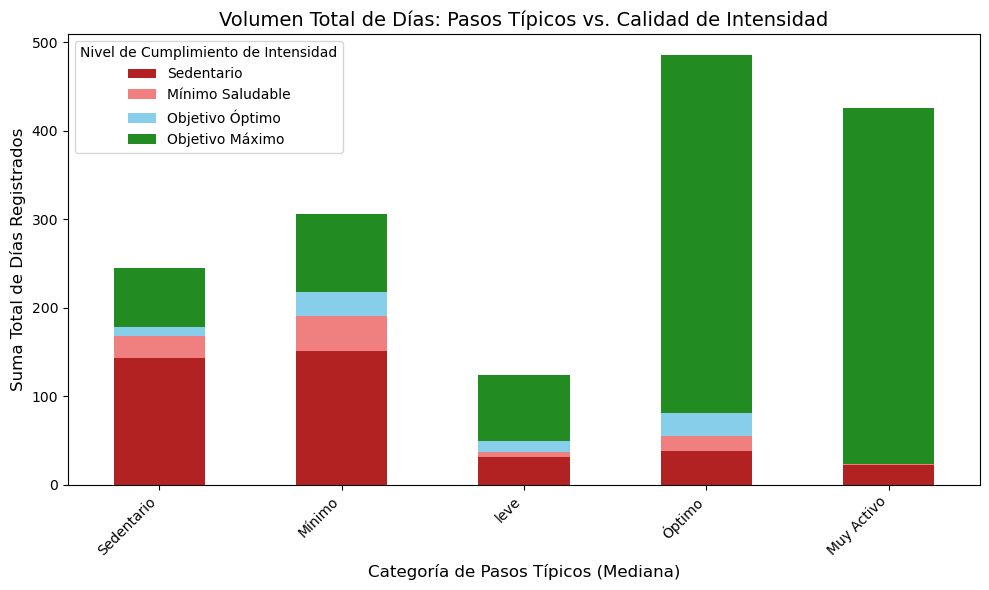

In [15]:
# 1. Definir el orden y colores de las categorías de Intensidad 

intensity_order = LI_INTENSITY_NAMES_ESP

colors = ['firebrick', 'lightcoral', 'skyblue', 'forestgreen']
color_map = dict(zip(intensity_order, ['firebrick', 'lightcoral', 'skyblue', 'forestgreen']))

# 2. Reordenar las columnas del DataFrame para que se apilen correctamente
df_plot = df_sum_steps_intensities.reindex(columns=intensity_order)

# 3. Crear el gráfico de barras apiladas
df_plot.plot(
    kind='bar', 
    stacked=True, 
    figsize=(10, 6), 
    color=[color_map[col] for col in intensity_order]
)

# 4. Añadir etiquetas y título
plt.title('Volumen Total de Días: Pasos Típicos vs. Calidad de Intensidad', fontsize=14)
plt.xlabel('Categoría de Pasos Típicos (Mediana)', fontsize=12)
plt.ylabel('Suma Total de Días Registrados', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Nivel de Cumplimiento de Intensidad', loc='upper left')
plt.tight_layout()
plt.show()

#### * Días de sueño
El dataset dispone de datos con registros de noches pero estos no han sido registrados por los sensores, 
si disponemos mejores registros de detección de sueño, hay un posible propuesta de marketing

In [16]:
# Cantidad dias que tienen registro de sueño 
print('Cantdad de dias con sueño registrados')
print(user_activity['count_Records'].sum())

# Cantidad de dias en el dataset
print('\nCantidad de días')
print(user_activity['days_of_sleep'].sum())

print('\nPorcentage de sueño registrados')
print(f"%{round(((user_activity['days_of_sleep'].sum()*100)/user_activity['count_Records'].sum()), 2)}")

Cantdad de dias con sueño registrados
1586

Cantidad de días
796

Porcentage de sueño registrados
%50.19


## -- .Correlaciones de datos diarios de clientes

### --- .Calorías con Intensidad
Correlación frente a la formula referente a la salud según la intencidad - **Combined_Activity_Score** : **0.76**  

#### Calorías frente la cantidad de minutos minutos según el nivel de intensidad saludable dentro de la semana

| **Intensidades** |  **Flag_Sedentary** | **Flag_Meets_Min_Health** |**Flag_Meets_Optimal_Goal** |**Flag_Meets_Best_Goal** |
| :--- | :--- | :--- | :--- | :--- | 
| **Calorías** | -0.48 | -0.12 | -0.09 | 0.53 | 


### --. Calorías frente la cantidad de minutos minutos según el nivel de intensidad 

| **Intensidades** | **SedentaryMinutes** | **LightActiveMinutes** | **ModeratelyActiveMinutes** | **VeryActiveMinutes** | 
| :--- | :--- | :--- | :--- | :--- | 
| **Calorías** |  -0.36 |  0.23 | 0.56 | 0.69 | 



### --. Calorías con Pasos
Correlación de la calorías frente a la cantidad de pasos - **Steps** : **0.61**  

### --. Pasos según el nivel de intensidad

| Intensidades |**SedentaryMinutes** | **LightActiveMinutes** | **ModeratelyActiveMinutes** | **VeryActiveMinutes** |
| :--- | :--- |  :--- |  :--- |  :--- | 
|  Steps |  -0.62 | 0.48 |  0.70 |  0.72 | 


In [17]:
merged_dailyActivity[['Calories', 'minutes_instances', 'Steps' ,'SedentaryMinutes', 'LightActiveMinutes', 'ModeratelyActiveMinutes', 'VeryActiveMinutes', 'Combined_Activity_Score', 'Flag_Sedentary', 'Flag_Meets_Min_Health', 'Flag_Meets_Optimal_Goal', 'Flag_Meets_Best_Goal']].corr()

,Calories,minutes_instances,Steps,SedentaryMinutes,LightActiveMinutes,ModeratelyActiveMinutes,VeryActiveMinutes,Combined_Activity_Score,Flag_Sedentary,Flag_Meets_Min_Health,Flag_Meets_Optimal_Goal,Flag_Meets_Best_Goal
Calories,1.000000,0.213744,0.614003,-0.361811,0.230470,0.568038,0.691517,0.761428,-0.484374,-0.120581,-0.090481,0.535275
minutes_instances,0.213744,1.000000,0.108469,0.512189,0.127454,0.086941,0.057421,0.081598,-0.085998,0.030325,-0.022964,0.073145
Steps,0.614003,0.108469,1.000000,-0.624914,0.476965,0.701818,0.726788,0.848676,-0.645934,-0.170748,-0.118082,0.717457
SedentaryMinutes,-0.361811,0.512189,-0.624914,1.000000,-0.651334,-0.622587,-0.366286,-0.551917,0.577059,0.105486,0.025989,-0.582326
LightActiveMinutes,0.230470,0.127454,0.476965,-0.651334,1.000000,0.426419,0.029812,0.218482,-0.574294,0.017920,0.061258,0.480807
ModeratelyActiveMinutes,0.568038,0.086941,0.701818,-0.622587,0.426419,1.000000,0.398737,0.749667,-0.589010,-0.169728,-0.123663,0.668226
VeryActiveMinutes,0.691517,0.057421,0.726788,-0.366286,0.029812,0.398737,1.000000,0.905848,-0.404627,-0.162756,-0.140941,0.506629
Combined_Activity_Score,0.761428,0.081598,0.848676,-0.551917,0.218482,0.749667,0.905848,1.000000,-0.564076,-0.195855,-0.158834,0.674279
Flag_Sedentary,-0.484374,-0.085998,-0.645934,0.577059,-0.574294,-0.589010,-0.404627,-0.564076,1.000000,-0.138052,-0.127897,-0.775985
Flag_Meets_Min_Health,-0.120581,0.030325,-0.170748,0.105486,0.017920,-0.169728,-0.162756,-0.195855,-0.138052,1.000000,-0.055079,-0.334178


# -------------------------------*

### ---
### Semanales
### ---

In [18]:
# calcular si hizo el ejercicio semanal
# definir persona activo      - como - cuanto
# definir persona sedentaria  - como - cuanto

# merged_dailyActivity.groupby(merged_dailyActivity['ActivityDay'].dt.isocalendar().week)
# merged_dailyActivity['ActivityDay'].dt.isocalendar().week
week_Activity = merged_dailyActivity.groupby(['Id','Week_ISO']).agg(
    initial_date = ('ActivityDay', 'min'),         # Find the earliest available date
    lastest_date = ('ActivityDay', 'max'),

    # # Días con datos registrados
    count_Records = ('ActivityDay', 'count'), 

    # no_Records    = ('ActivityDay', lambda x: ((x.max() - x.min()).days + 1) - x.count()),
    # # no_Records    = ('ActivityDay', lambda x : diff_days_range - x.count()),

    # Contar días dependiendo de la cantidad de pasos registrados
    std_steps      = ('Steps', 'std'),
    median_steps   = ('Steps', 'median'),
    mean_steps     = ('Steps', 'mean'),
    min_steps      = ('Steps', 'min'),
    max_steps      = ('Steps', 'max'),

    q1_steps      = ('Steps', lambda x: x.quantile(0.25)),  # Cuartil 1 (25%)
    q3_steps      = ('Steps', lambda x: x.quantile(0.75))   # Cuartil 3 (75%)

     ##########################################################################
    # mov_VeryActive  = ('Steps', lambda x: ((x >= 10000)).sum()),
    # mov_Moderately  = ('Steps', lambda x: ((x >= 7500) & (x < 10000)).sum()),
    # mov_Light       = ('Steps', lambda x: ((x >= 5000) & (x < 7500 )).sum()),
    # mov_Sedentary   = ('Steps', lambda x: ((x >= 0   ) & (x < 5000 )).sum()),




    # # Días que tienen registrado su actividad de sueño y si estos son de  sueño saludable ( mínimo 7 horas)
    # days_of_sleep  = ('TotalMinutesAsleep', lambda x: (x > 0).sum()),
    # healthy_sleep  = ('TotalMinutesAsleep', lambda x: (x > 420).sum()),
 

    # # Puntos de actividad
    # Combined_Activity_Score    = ('Combined_Activity_Score', 'sum'),
    # Min_Healty_Week_Goal       = ('Combined_Activity_Score', lambda x : x.sum() >= (x.count() * MIN_HEALTH_GOAL_DAILY)),
    # Optimal_Goal_week_Goal     = ('Combined_Activity_Score', lambda x : x.sum() >= (x.count() * OPTIMAL_GOAL_DAILY)),
    # Best_Goal_week_Goal        = ('Combined_Activity_Score', lambda x : x.sum() >= (x.count() * BEST_GOAL_DAILY)),

    # healthy_days = ('Flag_Meets_Best_Goal', lambda x : x.sum() >= 3), # Personas hacen actividad física 
                                                        
    # # Días con actividad física y suficiente
    # Flag_Meets_Min_Health    = ('Flag_Meets_Min_Health', 'sum'),
    # Flag_Meets_Optimal_Goal  = ('Flag_Meets_Optimal_Goal', 'sum'),
    # Flag_Meets_Best_Goal     = ('Flag_Meets_Best_Goal', 'sum'),
    # Flag_Meets_Less_Min_Goal = ('Flag_Meets_Min_Health', lambda x : (x == 0).sum()),
     ##########################################################################
)

# Combined_Activity_Score / dias(coun/sum)
week_Activity

# # *** 1. Definición de Metas Diarias (Basado en OMS) ***
# # Minuto de salud mínimo (150 min/semana / 7 días ≈ 21.4 minutos)
# MIN_HEALTH_GOAL_DAILY = 22 

# # Meta Óptima (Tu punto medio de 225 min/semana / 7 días ≈ 32.14 minutos)
# OPTIMAL_GOAL_DAILY = 32

initial_date lastest_date  count_Records    std_steps  \
Id         Week_ISO                                                         
1503960366 10         2016-03-12   2016-03-13              2  1816.557321   
           11         2016-03-14   2016-03-20              7  1896.518828   
           12         2016-03-21   2016-03-27              7  2528.195168   
           13         2016-03-28   2016-04-03              7  1043.820524   
           14         2016-04-04   2016-04-10              7  1874.024966   
...                          ...          ...            ...          ...   
8877689391 15         2016-04-11   2016-04-17              7  6500.689040   
           16         2016-04-18   2016-04-24              7  3693.841032   
           17         2016-04-25   2016-05-01              7  7015.924499   
           18         2016-05-02   2016-05-08              7  5504.237359   
           19         2016-05-09   2016-05-12              4  7023.092054   

                     median_steps    mean_steps  min_steps  max_steps  \
Id         Week_ISO                                                     
1503960366 10             18390.5  18390.500000      17106      19675   
           11             14544.0  14004.000000      10023      15424   
           12             13188.0  13317.857143      10020      17609   
           13             12041.0  11701.428571      10016      13231   
           14             12432.0  12366.285714      10057      14844   
...                           ...           ...        ...        ...   
8877689391 15             15337.0  18264.000000      10557      29204   
           16             18225.0  16498.714286      11191      19881   
           17             12957.0  15830.714286       9700      27710   
           18             12212.0  13172.714286       4699      21622   
           19             15424.5  14840.000000       7120      21391   

                     q1_steps  q3_steps  
Id         Week_ISO                      
1503960366 10        17748.25  19032.75  
           11        13762.50  15256.00  
           12        11870.00  14334.00  
           13        11109.00  12202.00  
           14        11086.00  13529.50  
...                       ...       ...  
8877689391 15        14246.50  22128.50  
           16        14034.50  19062.50  
           17        10980.00  19244.00  
           18        10728.00  16110.00  
           19         9799.75  20464.75  

[259 rows x 10 columns]

In [19]:
week_Activity[['initial_date' , 'lastest_date' , 'count_Records' , 'std_steps' , 'median_steps' ]].head(10)


# df.groupby('columna_agrupadora')['columna_de_interes'].std()

initial_date lastest_date  count_Records    std_steps  \
Id         Week_ISO                                                         
1503960366 10         2016-03-12   2016-03-13              2  1816.557321   
           11         2016-03-14   2016-03-20              7  1896.518828   
           12         2016-03-21   2016-03-27              7  2528.195168   
           13         2016-03-28   2016-04-03              7  1043.820524   
           14         2016-04-04   2016-04-10              7  1874.024966   
           15         2016-04-11   2016-04-17              7  1365.504407   
           16         2016-04-18   2016-04-24              7  2223.006437   
           17         2016-04-25   2016-05-01              7  2564.894995   
           18         2016-05-02   2016-05-08              7  1912.327179   
           19         2016-05-09   2016-05-11              3   159.236721   

                     median_steps  
Id         Week_ISO                
1503960366 10             18390.5  
           11             14544.0  
           12             13188.0  
           13             12041.0  
           14             12432.0  
           15             10735.0  
           16             12764.0  
           17             13755.0  
           18             12159.0  
           19             12022.0

In [20]:
test2 = merged_dailyActivity.groupby(['Week_ISO']).agg(
    initial_date = ('ActivityDay', 'min'),         # Find the earliest available date
    lastest_date = ('ActivityDay', 'max'),

    # # Días con datos registrados
    count_Records = ('ActivityDay', 'count'), 

    # no_Records    = ('ActivityDay', lambda x: ((x.max() - x.min()).days + 1) - x.count()),
    # # no_Records    = ('ActivityDay', lambda x : diff_days_range - x.count()),

    # Contar días dependiendo de la cantidad de pasos registrados
    mov_VeryActive  = ('Steps', lambda x: ((x >= 10000)).sum()),
    mov_Moderately  = ('Steps', lambda x: ((x >= 7500) & (x < 10000)).sum()),
    mov_Light       = ('Steps', lambda x: ((x >= 5000) & (x < 7500 )).sum()),
    mov_Sedentary   = ('Steps', lambda x: ((x >= 0   ) & (x < 5000 )).sum()),


    # Días que tienen registrado su actividad de sueño y si estos son de  sueño saludable ( mínimo 7 horas)
    days_of_sleep  = ('TotalMinutesAsleep', lambda x: (x > 0).sum()),
    healthy_sleep  = ('TotalMinutesAsleep', lambda x: (x > 420).sum()),
 

    # Puntos de actividad
    Combined_Activity_Score    = ('Combined_Activity_Score', 'sum'),
    # Min_Healty_Week_Goal       = ('Combined_Activity_Score',  'count'), #lambda x : x.sum() >= (x.count() * MIN_HEALTH_GOAL_DAILY)),
    # Optimal_Goal_week_Goal     = ('Combined_Activity_Score',  'count'), #lambda x : x.sum() >= (x.count() * OPTIMAL_GOAL_DAILY)),
    # Best_Goal_week_Goal        = ('Combined_Activity_Score',  'count'), #lambda x : x.sum() >= (x.count() * BEST_GOAL_DAILY)),

    # healthy_days = ('Flag_Meets_Best_Goal', lambda x : x.sum() >= 3), # Personas hacen actividad física 
                                                        
    # ############################################# 
    # Días con actividad física y suficiente
    Flag_Meets_Min_Health    = ('Flag_Meets_Min_Health', 'sum'),
    Flag_Meets_Optimal_Goal  = ('Flag_Meets_Optimal_Goal', 'sum'),
    Flag_Meets_Best_Goal     = ('Flag_Meets_Best_Goal', 'sum'),
    Flag_Meets_Less_Min_Goal = ('Flag_Meets_Min_Health', lambda x : (x == 0).sum()),

    # ############################################# 
     
)
test2

,initial_date,lastest_date,count_Records,mov_VeryActive,mov_Moderately,mov_Light,mov_Sedentary,days_of_sleep,healthy_sleep,Combined_Activity_Score,Flag_Meets_Min_Health,Flag_Meets_Optimal_Goal,Flag_Meets_Best_Goal,Flag_Meets_Less_Min_Goal
Week_ISO,,,,,,,,,,,,,,
10,2016-03-12,2016-03-13,52,17,8,5,22,27,16,5832,4,3,30,48
11,2016-03-14,2016-03-20,182,67,22,21,72,85,45,19447,10,5,113,172
12,2016-03-21,2016-03-27,182,53,18,21,90,84,45,16395,10,9,98,172
13,2016-03-28,2016-04-03,182,59,28,31,64,104,55,20882,13,3,125,169
14,2016-04-04,2016-04-10,177,65,27,34,51,92,44,21554,3,11,128,174
15,2016-04-11,2016-04-17,178,60,27,31,60,88,43,19955,12,11,111,166
16,2016-04-18,2016-04-24,182,64,32,28,58,85,47,21289,11,13,121,171
17,2016-04-25,2016-05-01,182,67,28,33,54,99,45,21530,12,8,128,170
18,2016-05-02,2016-05-08,181,58,25,34,64,90,35,19031,12,9,122,169
